Streaming and analyzing graphs for n=10...
17 16 390


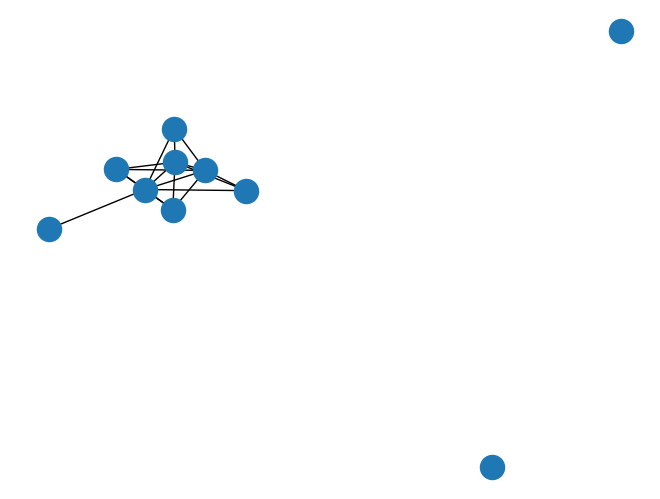

17 16 396


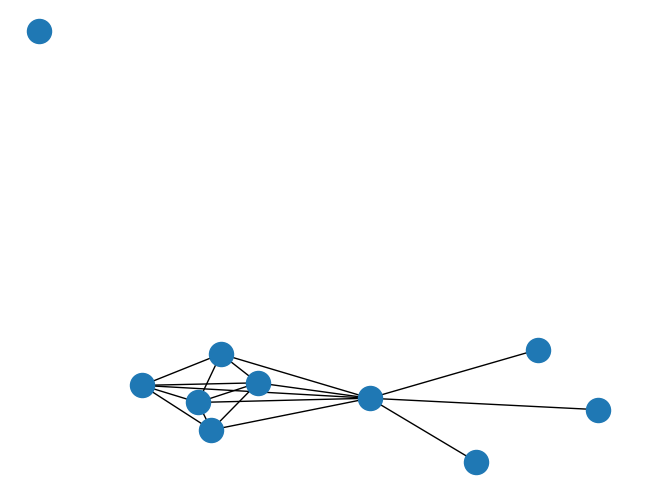

17 17 435


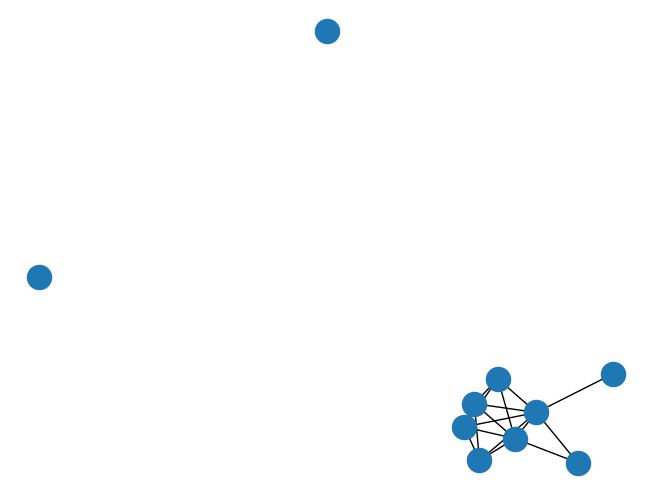

17 16 396


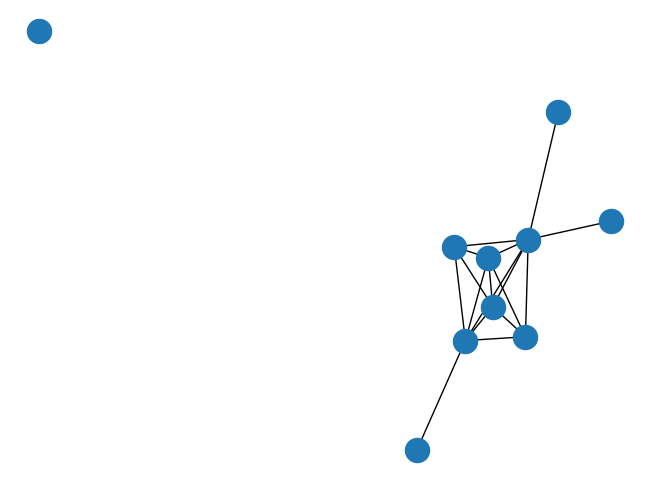

17 16 382


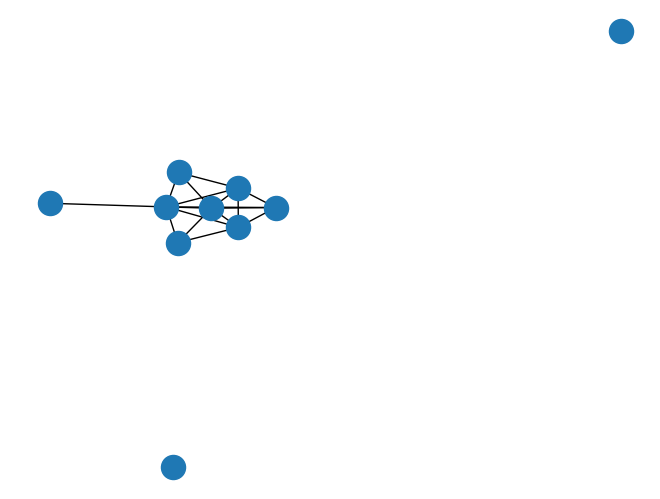

17 19 525


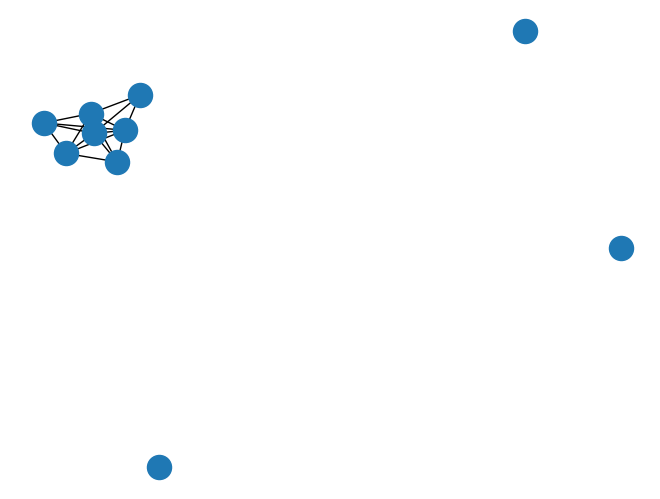

17 17 435


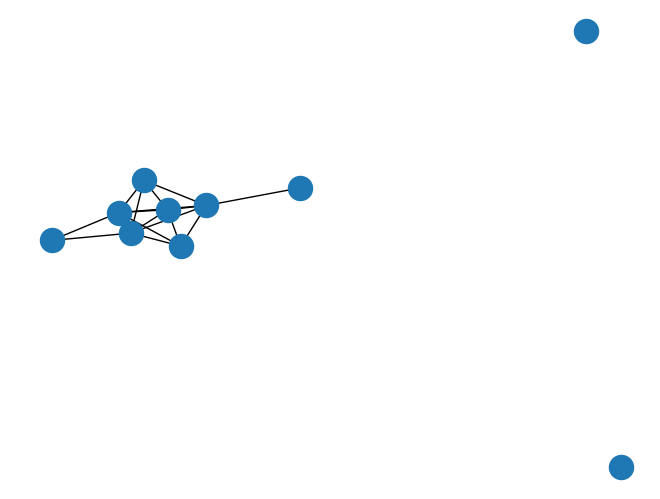

17 16 396


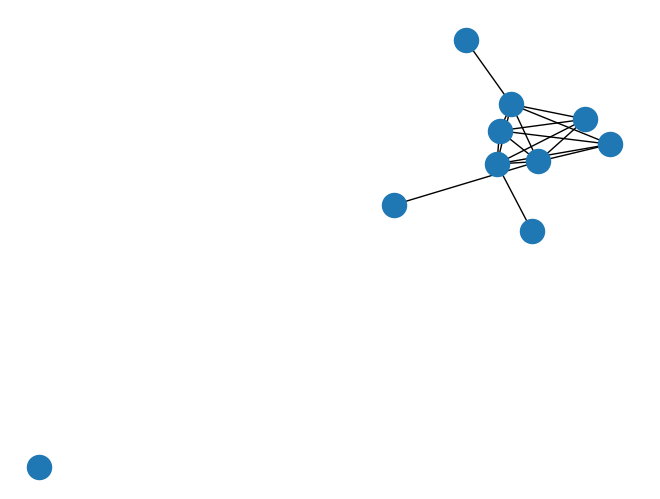

17 16 382


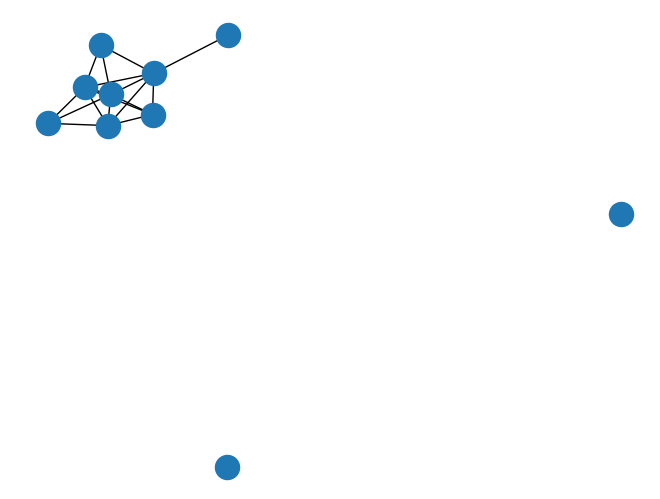

17 16 390


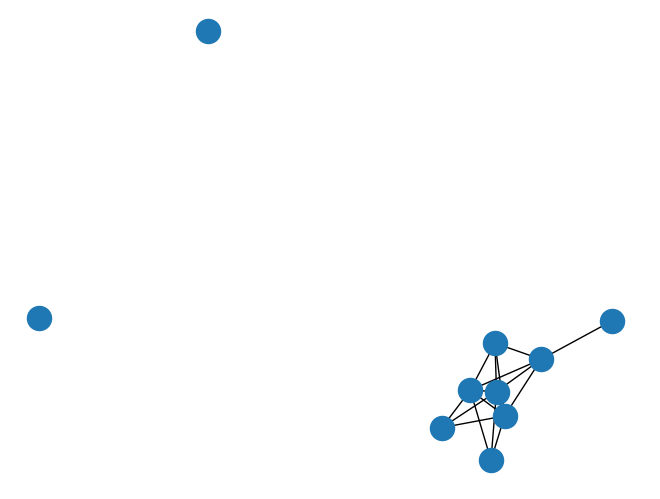

17 17 415


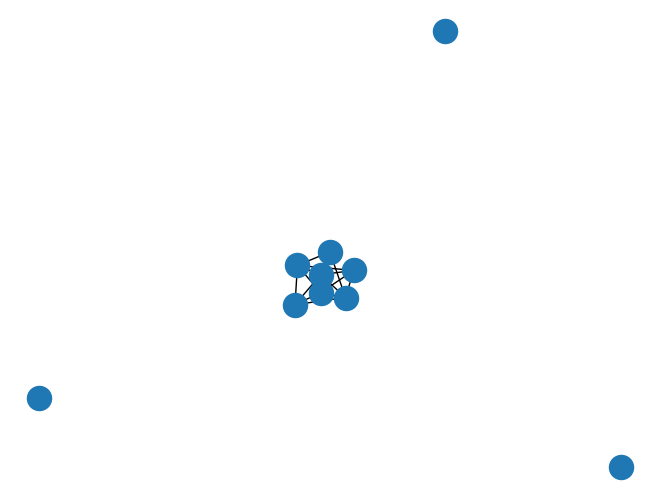

17 16 370


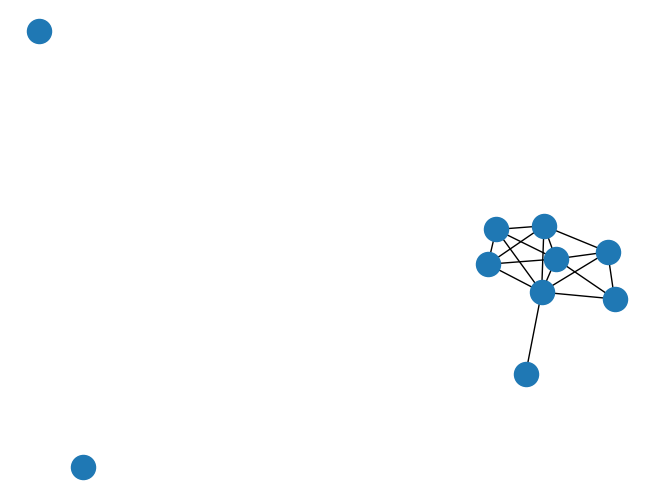

17 16 390


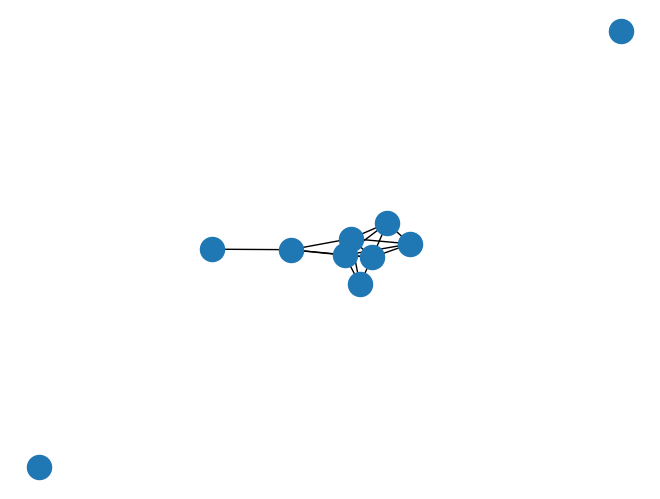

17 16 370


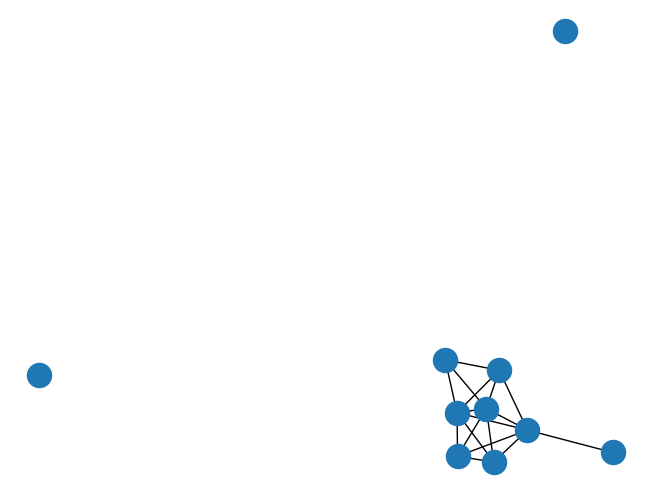

17 16 390


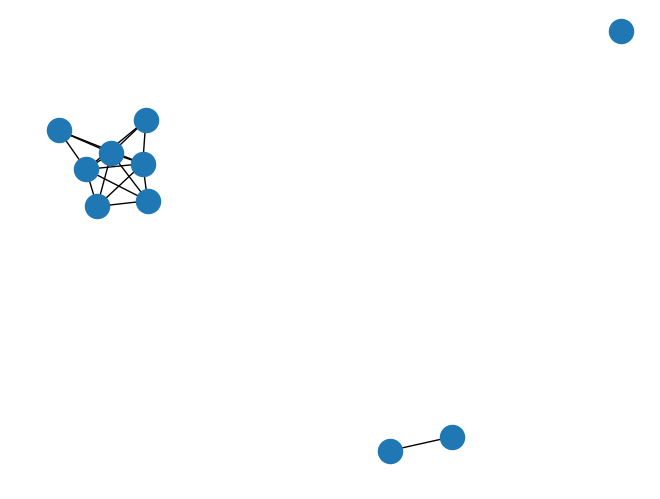

17 19 507


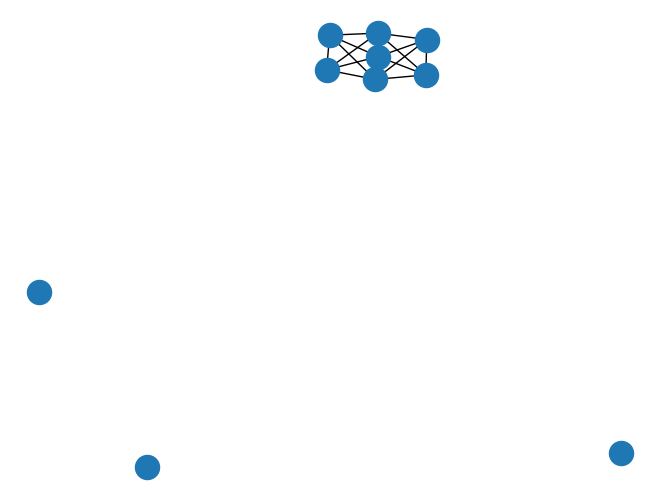

17 18 456


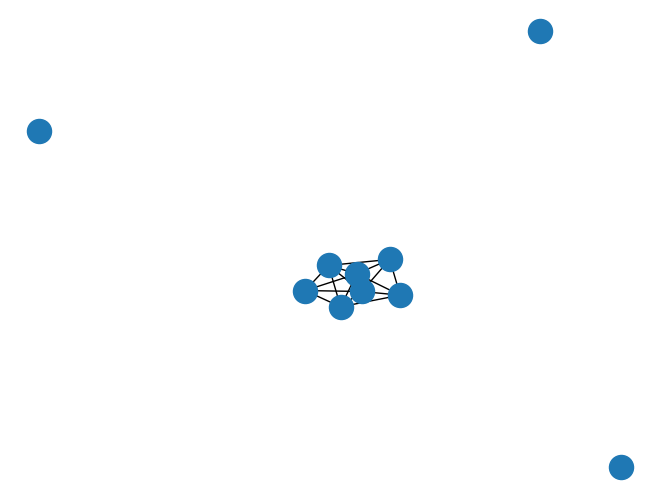

17 16 396


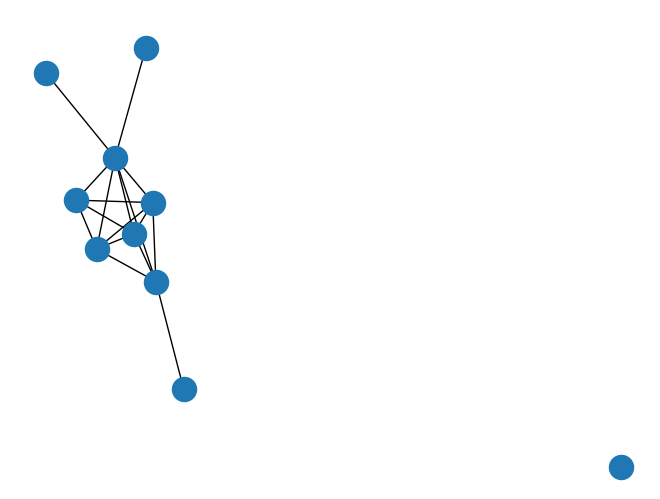

17 17 429


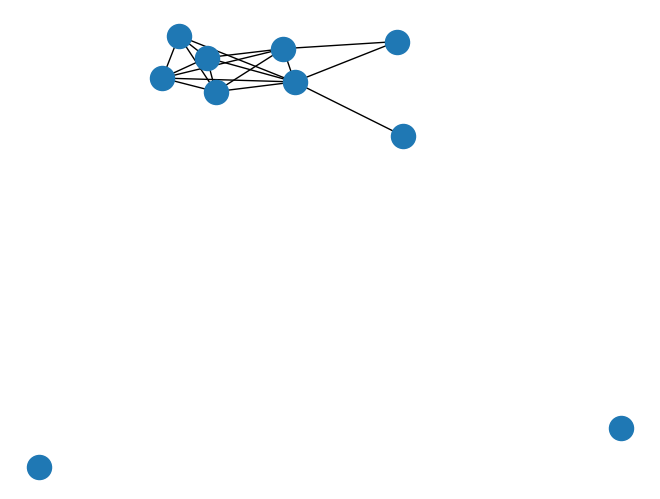

17 16 374


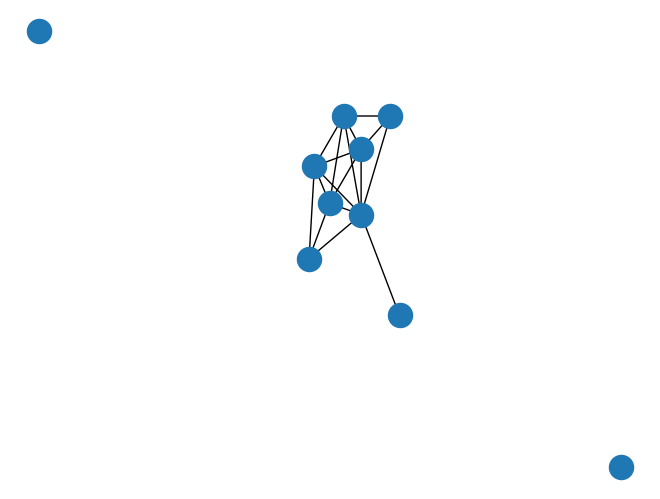

17 17 435


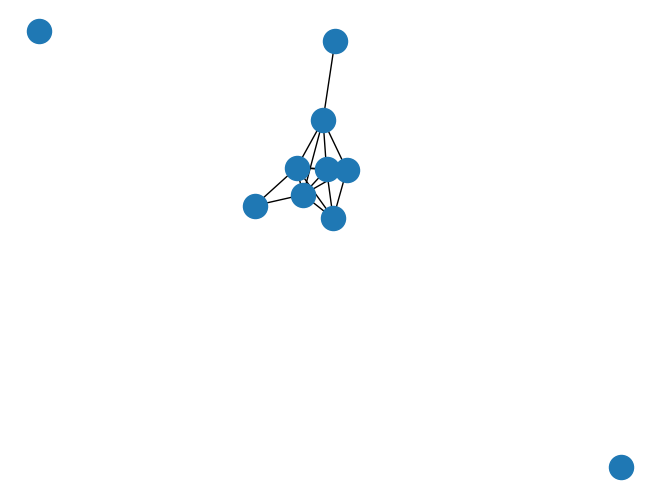

17 16 396


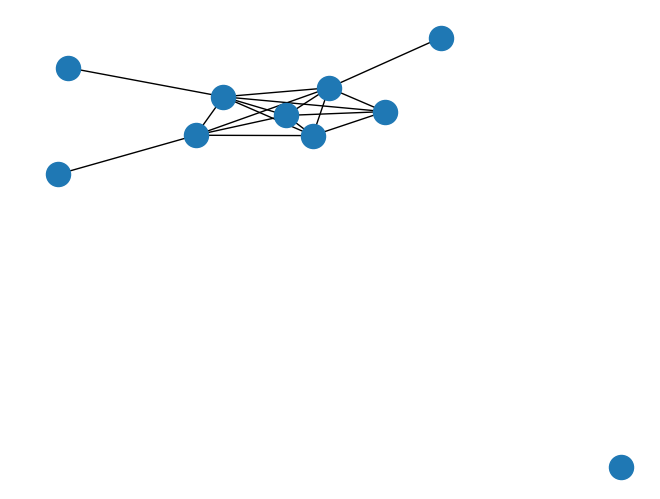

17 17 429


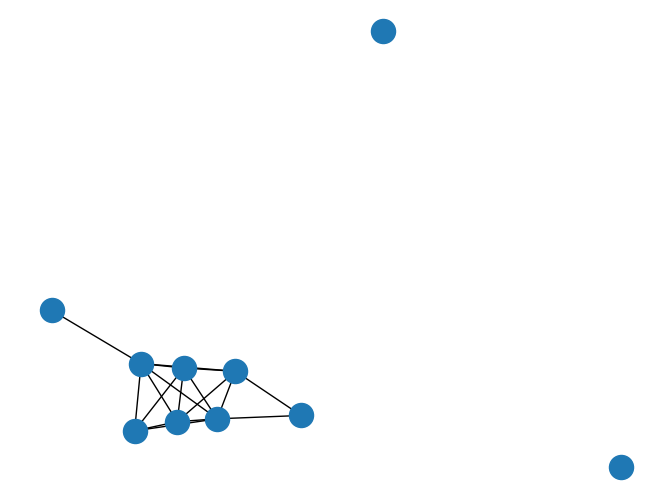

17 19 513


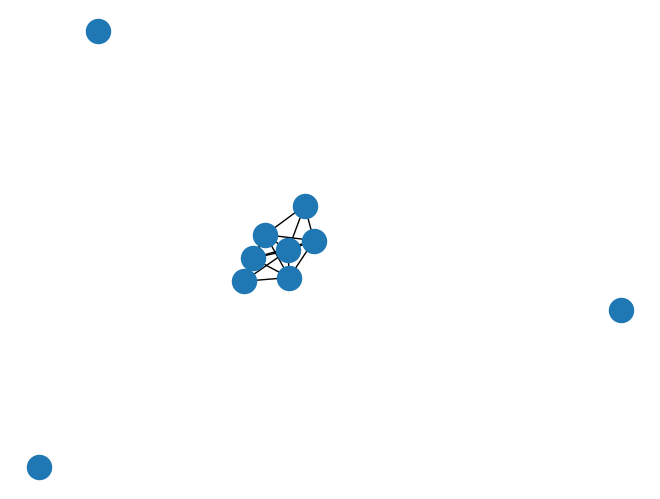

17 16 374


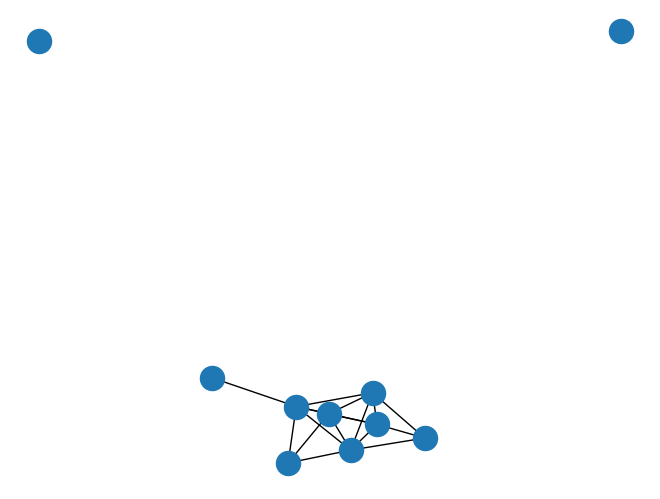

17 16 382


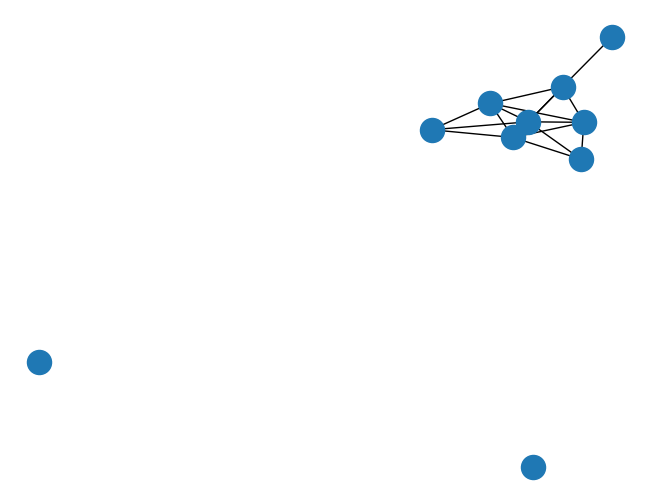

17 17 397


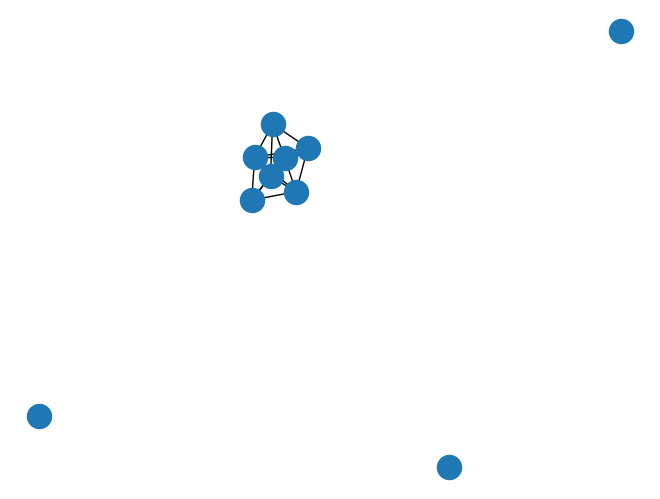

17 16 370


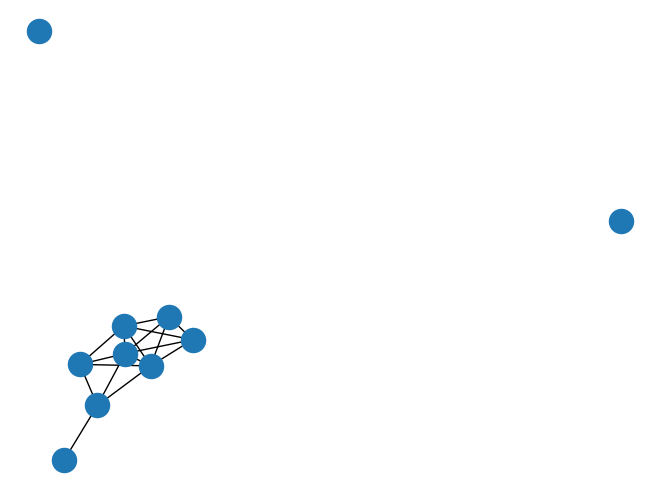

17 16 382


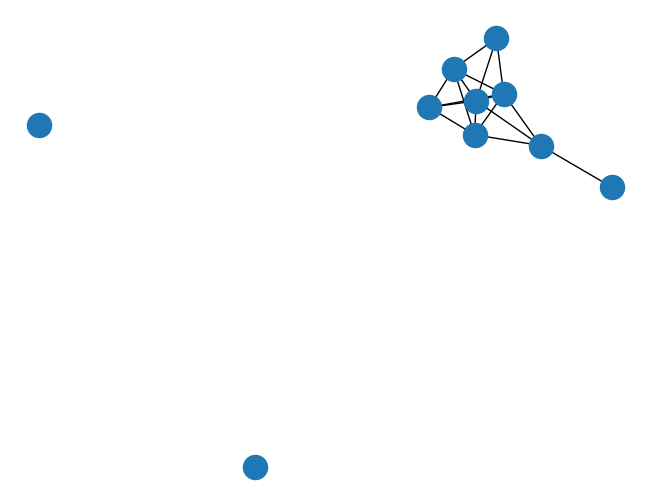

17 16 370


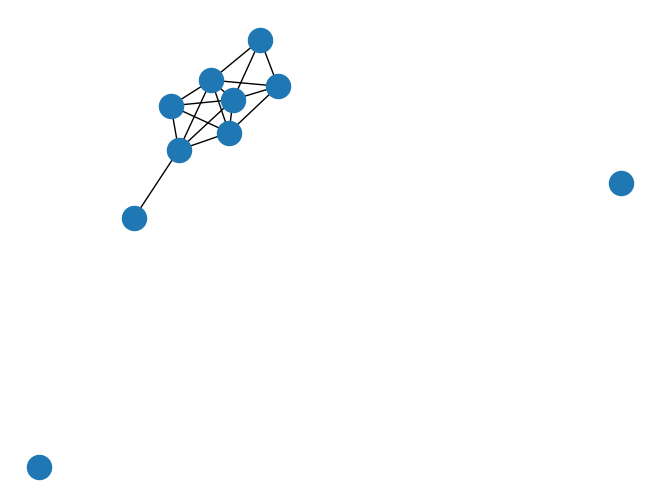

17 16 396


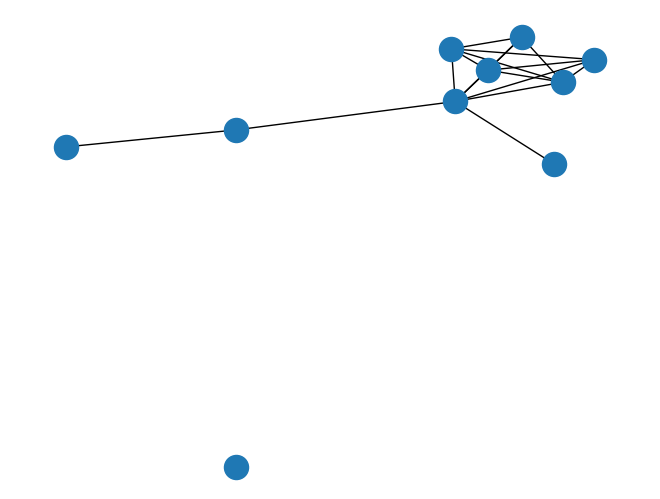

17 16 396


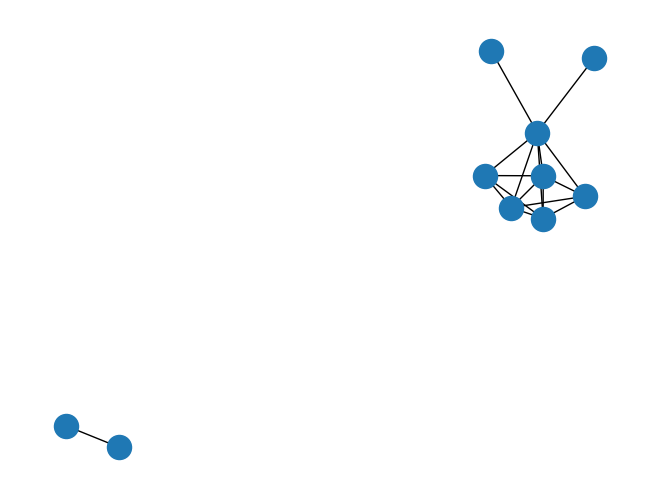

17 17 417


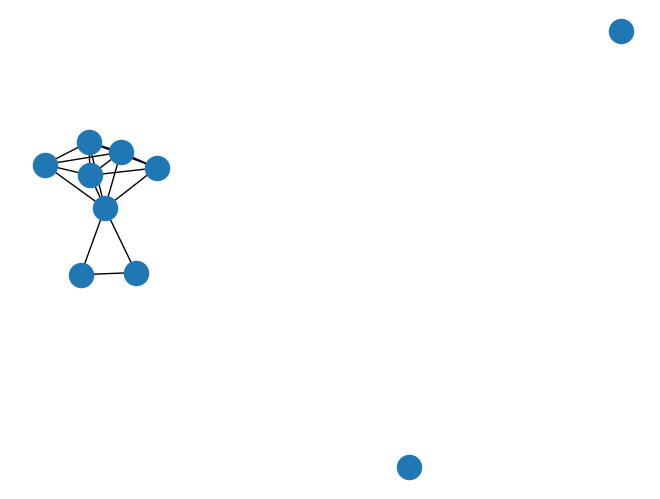

17 17 435


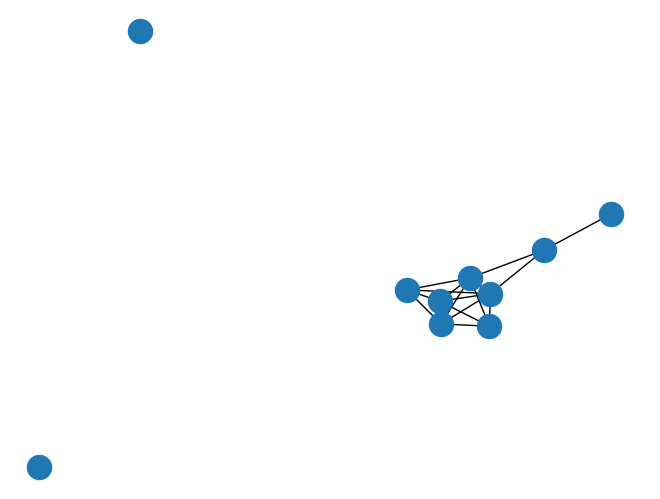

17 16 396


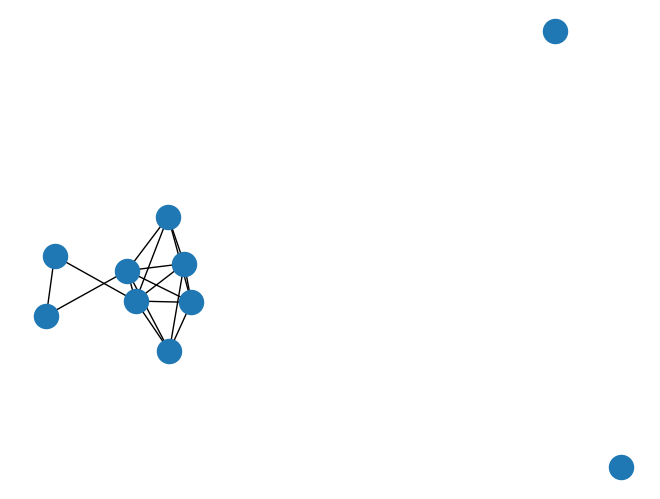

17 16 396


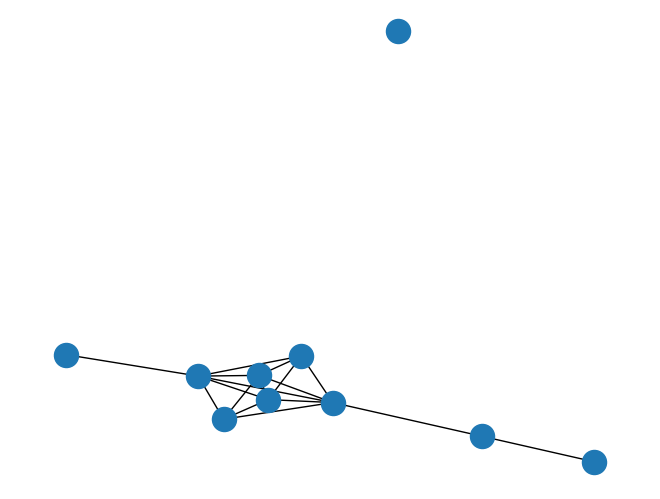

17 17 435


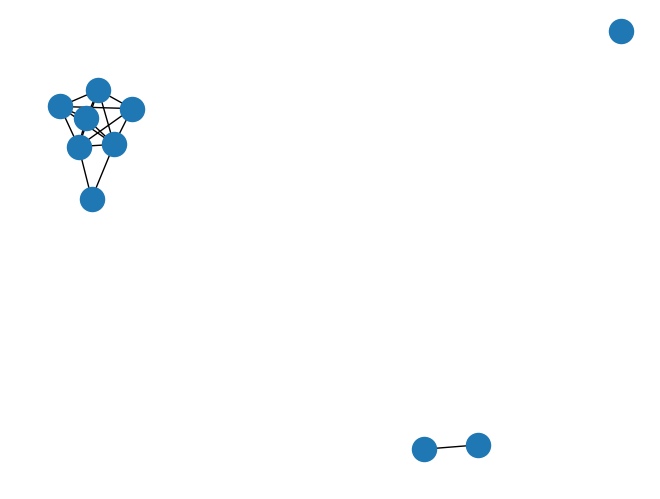

17 16 396


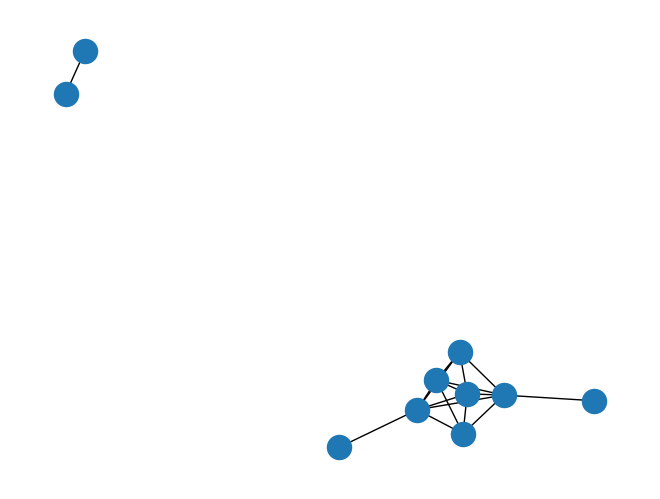

17 16 382


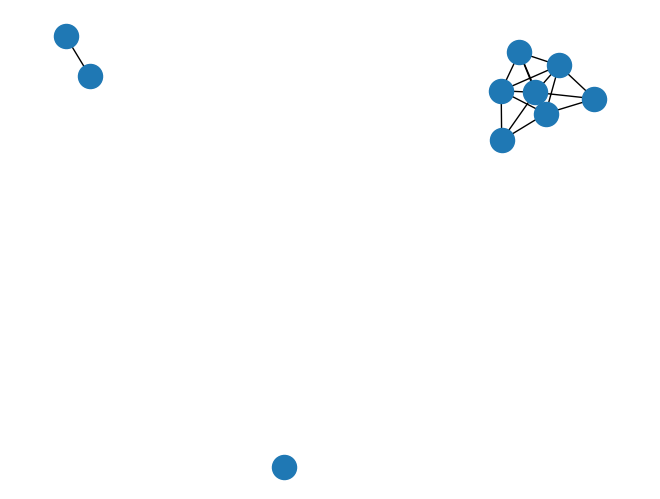

17 16 370


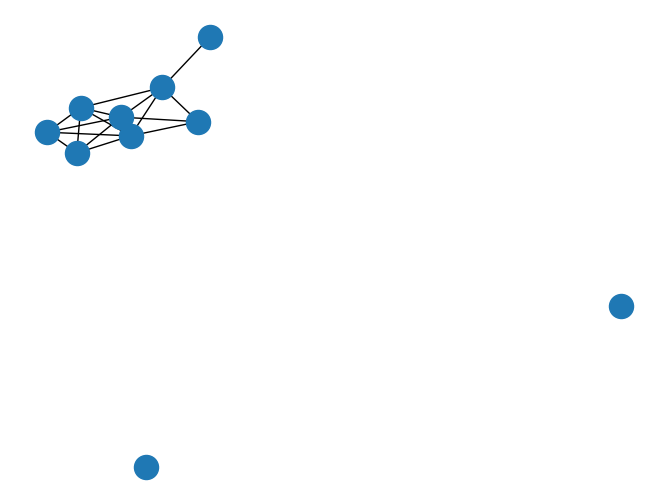

17 16 396


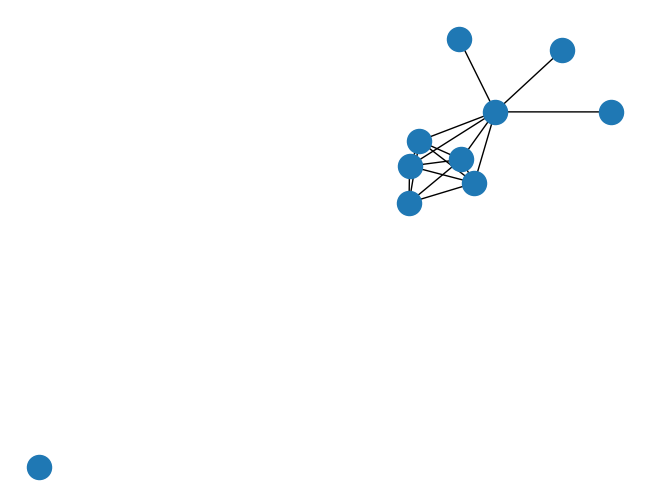

17 20 600


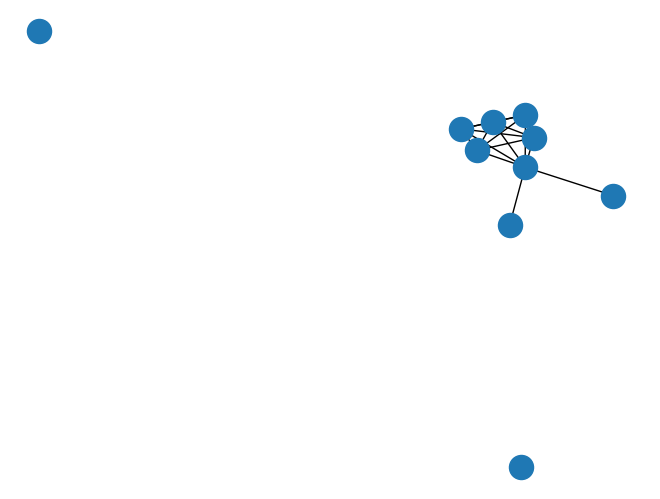

17 17 429


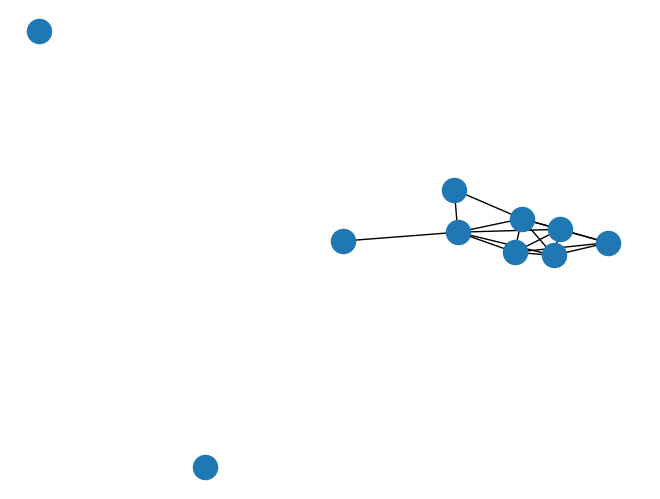

17 16 396


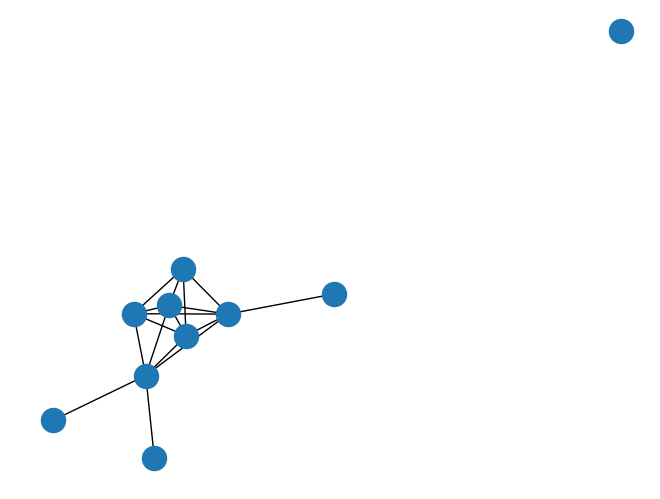

17 16 396


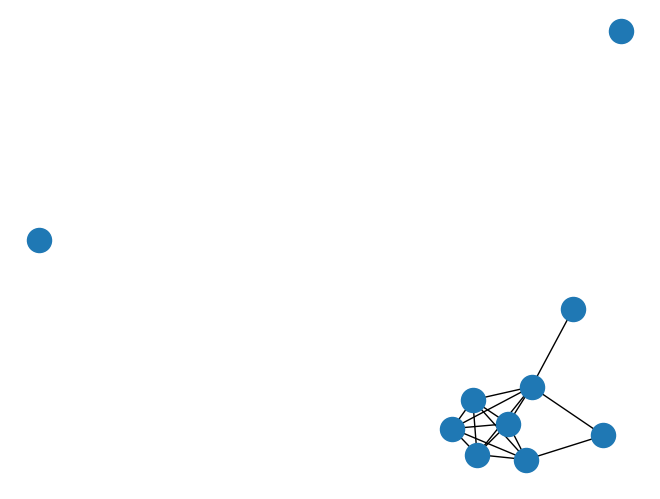

17 16 396


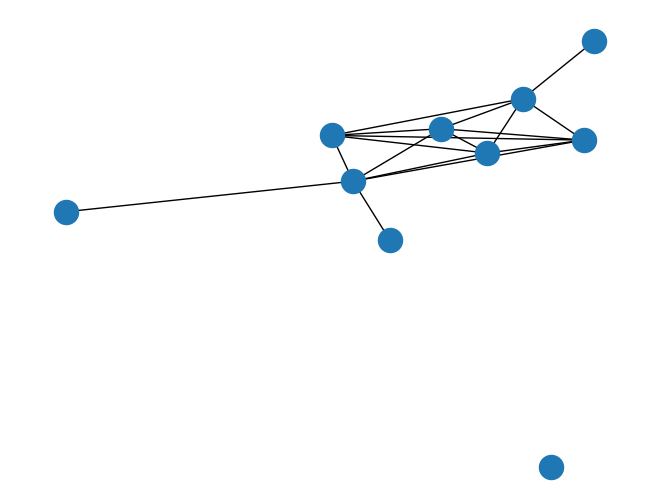

17 21 643


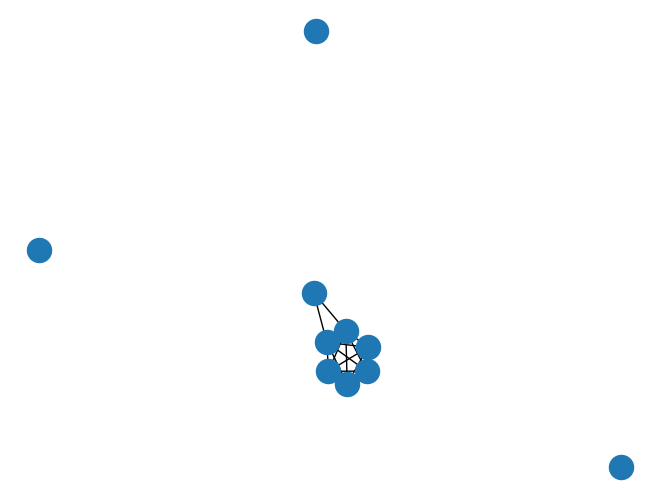

17 20 600


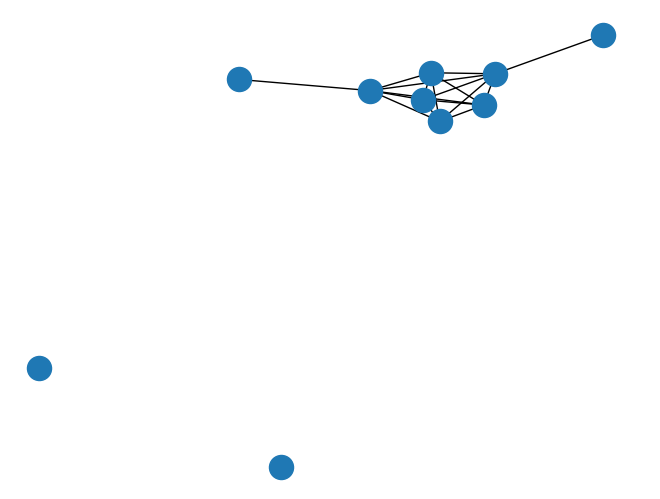

17 18 466


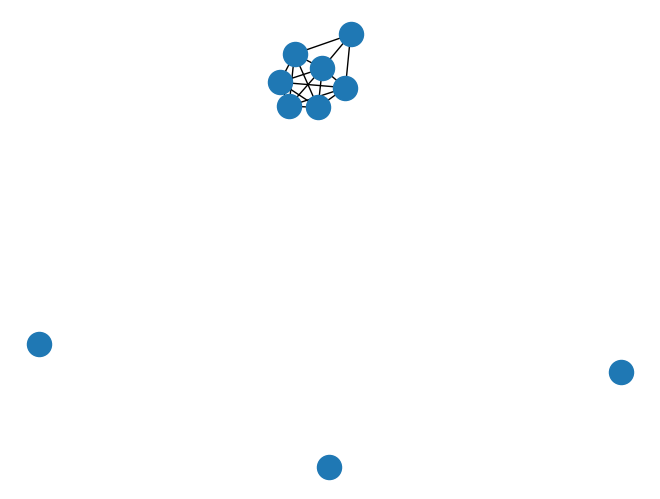

17 16 396


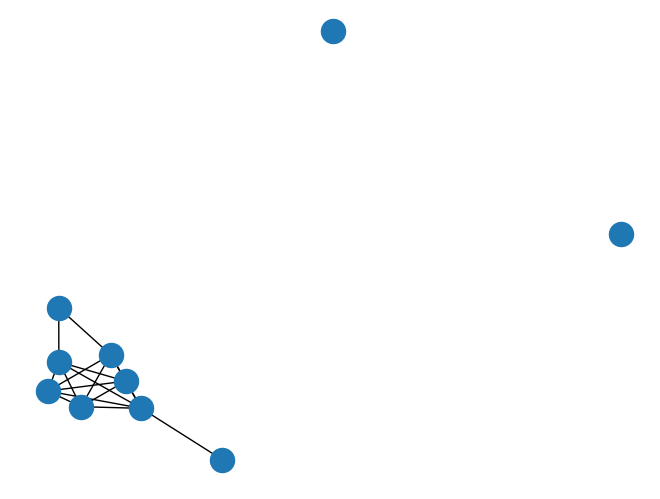

17 17 429


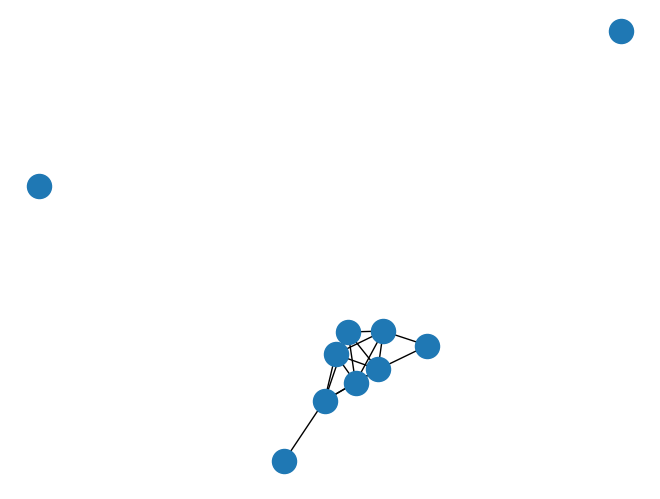

17 16 396


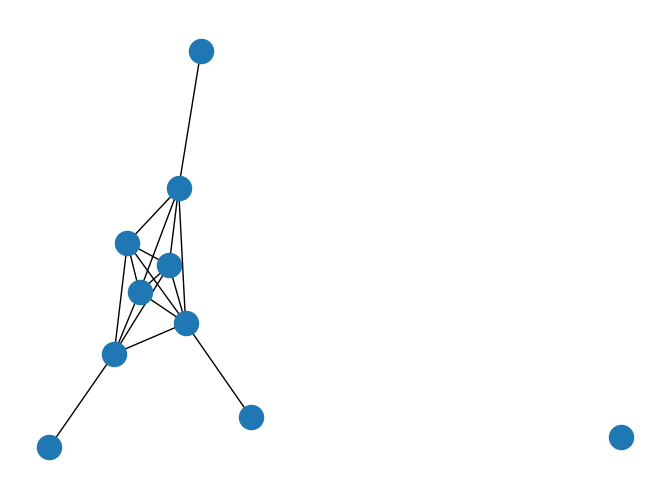

17 17 409


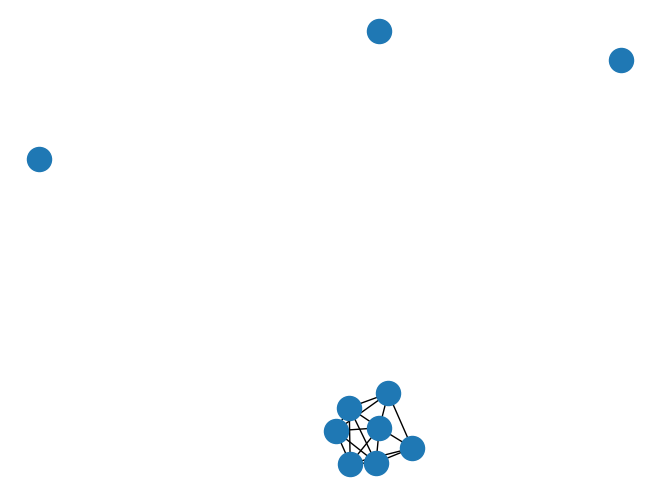

17 16 340


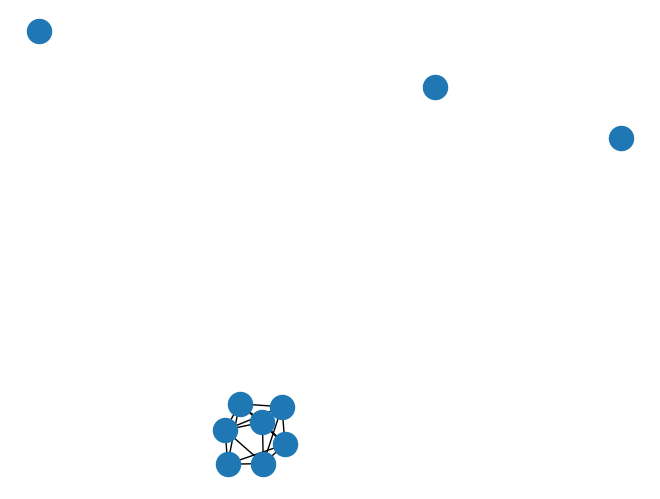

17 16 396


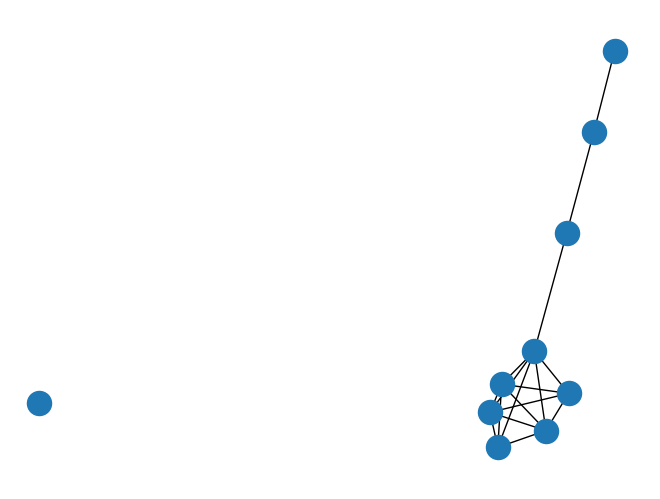

17 16 396


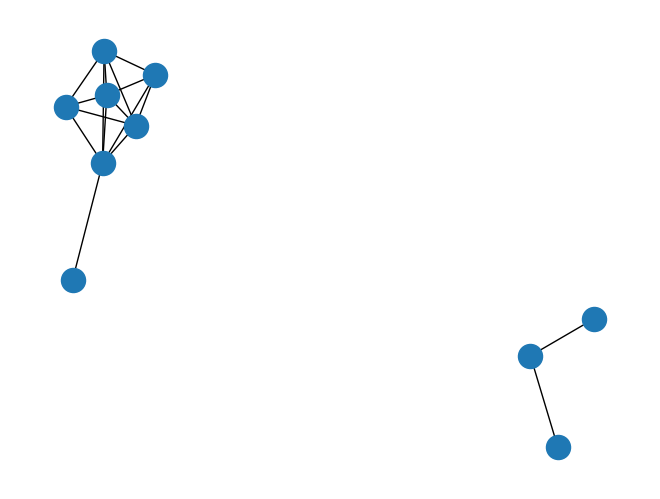

17 16 396


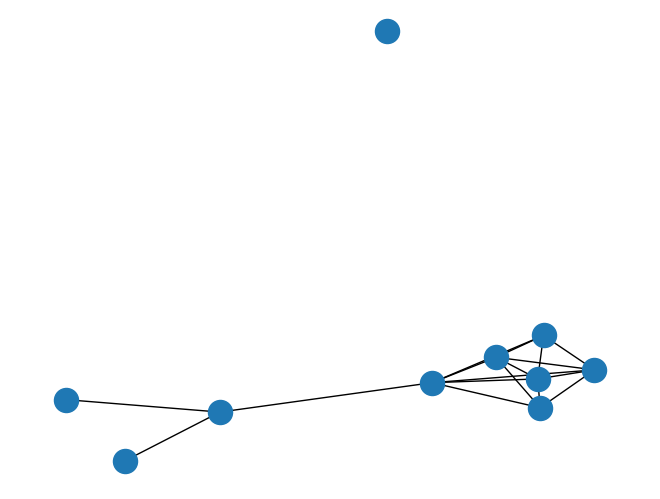

17 16 396


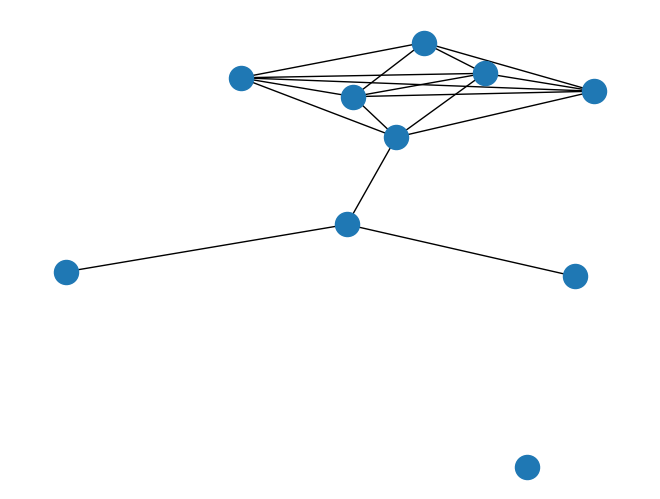

17 16 396


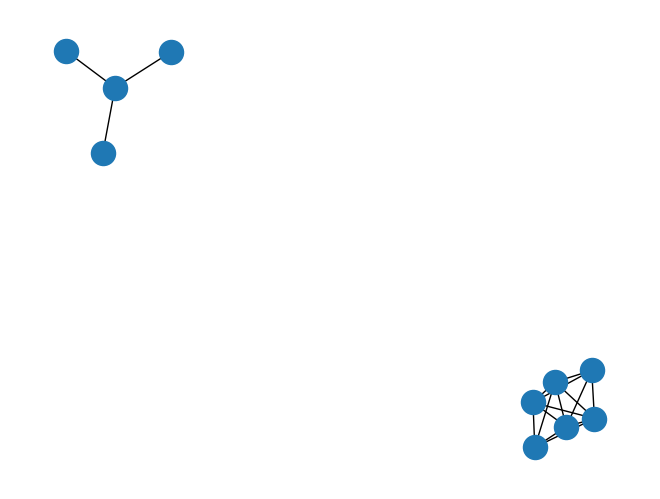

17 16 370


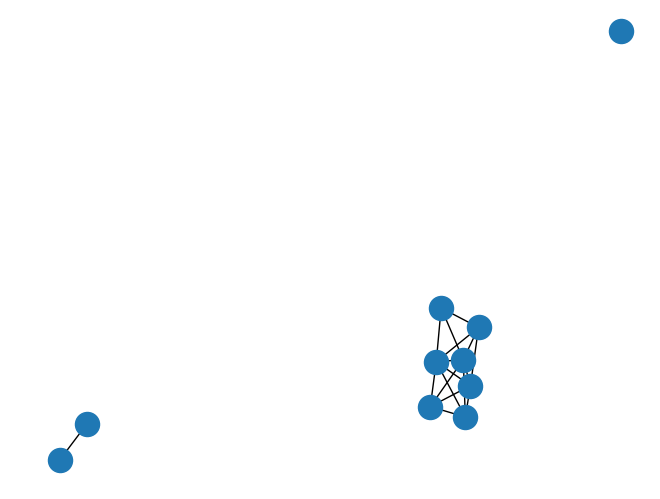

17 16 396


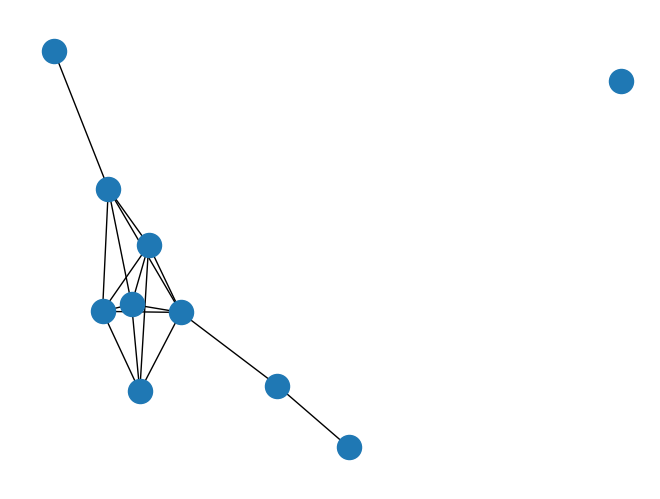

17 16 396


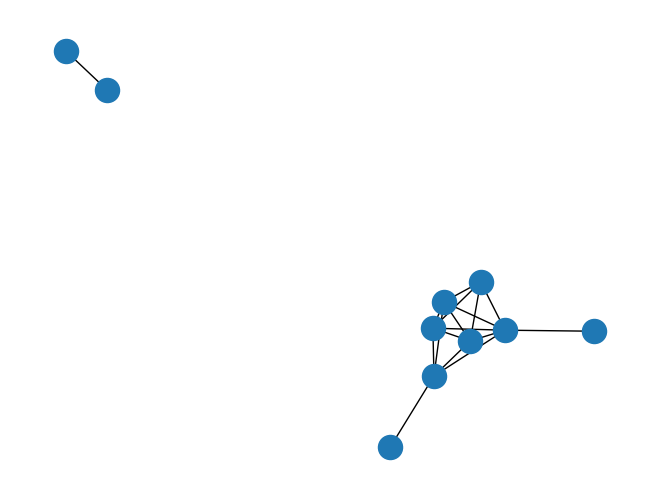

17 17 429


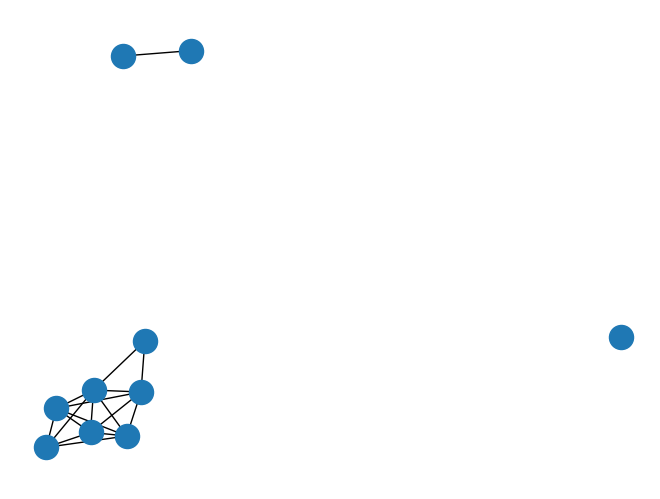

17 16 374


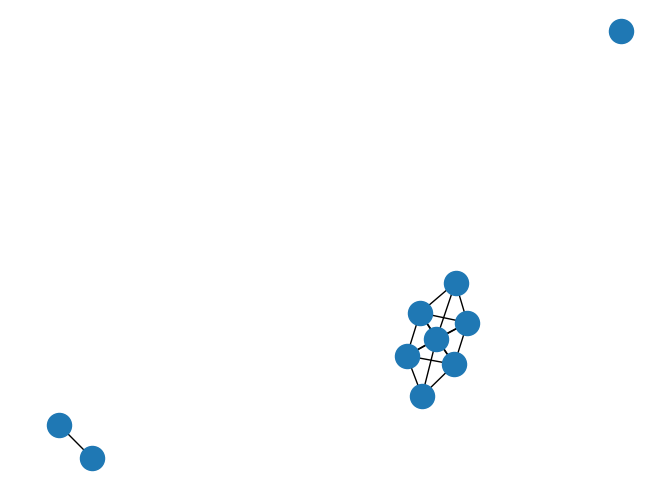

17 16 396


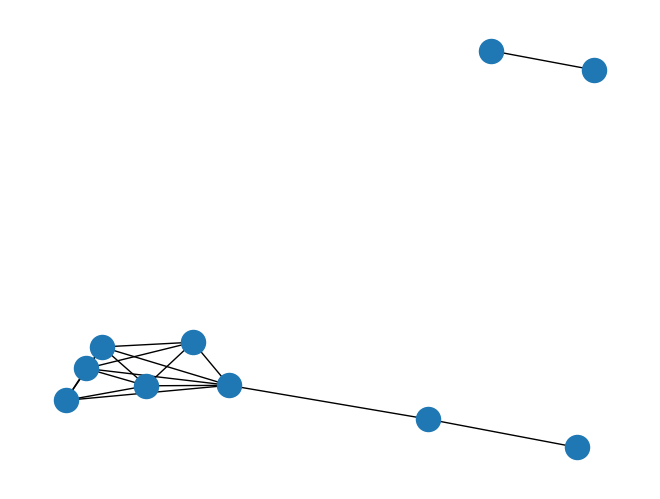

17 16 374


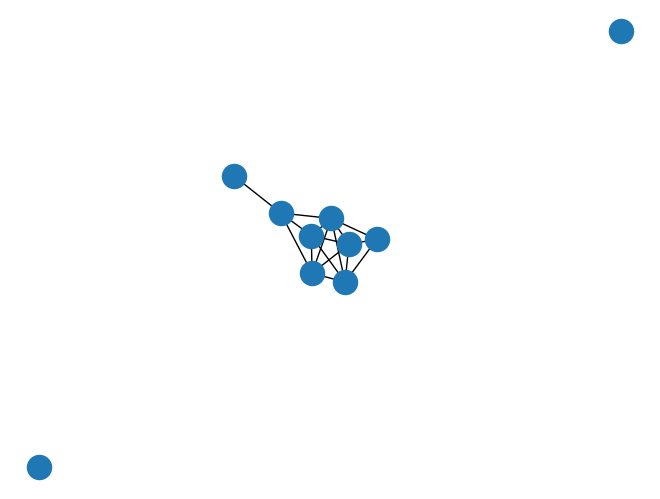

17 17 429


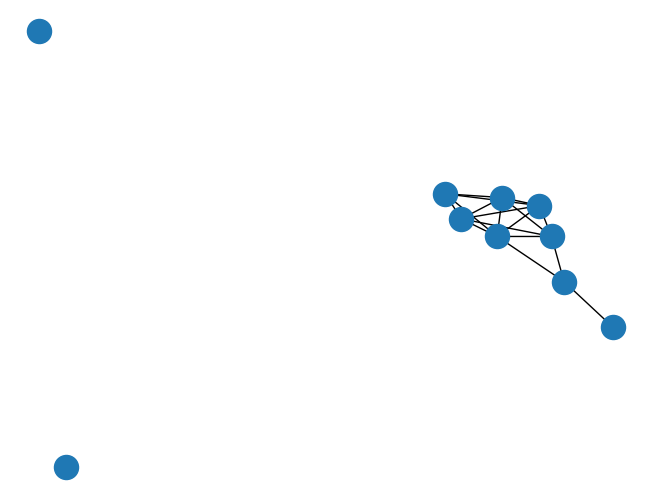

17 16 396


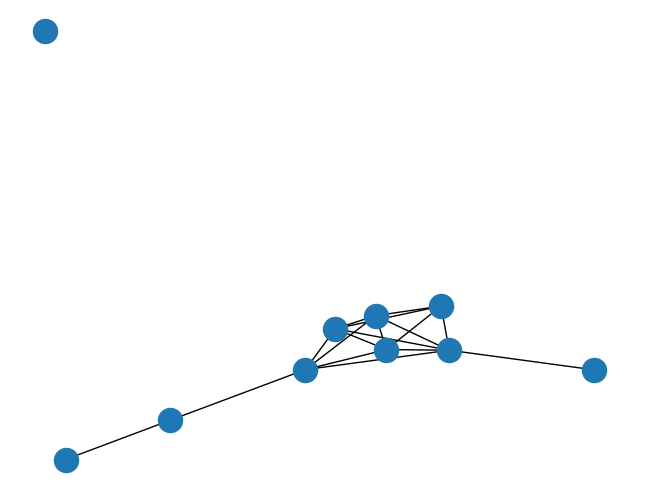

17 16 396


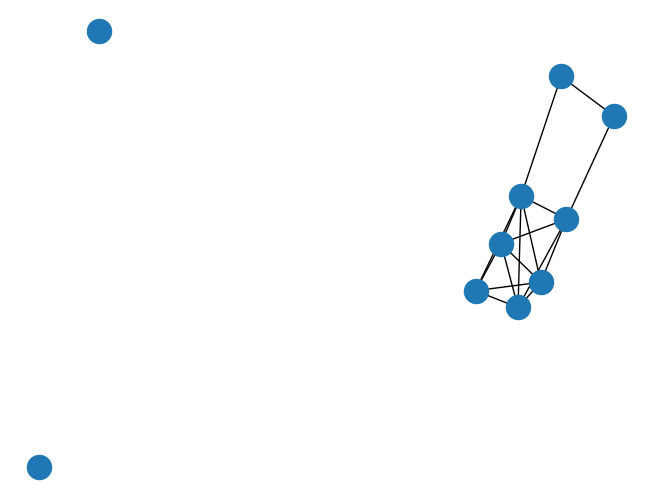

17 16 396


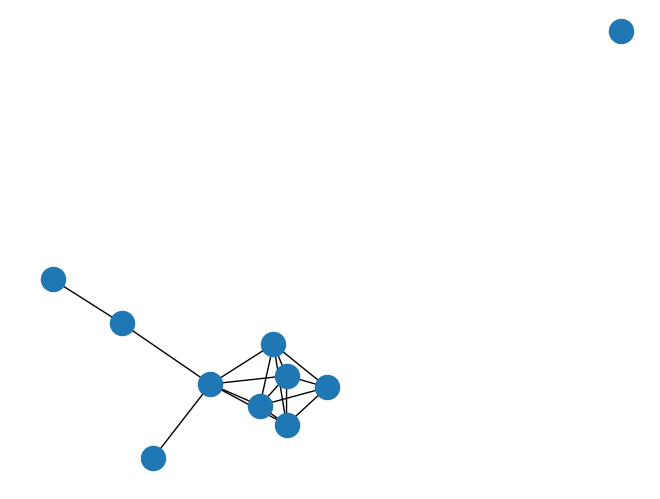

17 16 396


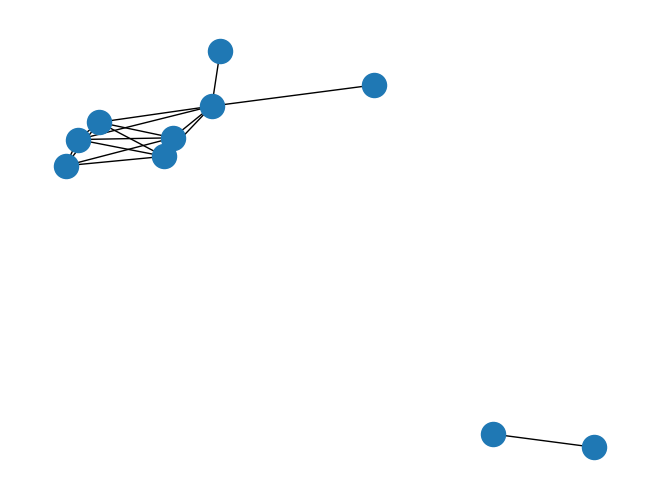

17 17 411


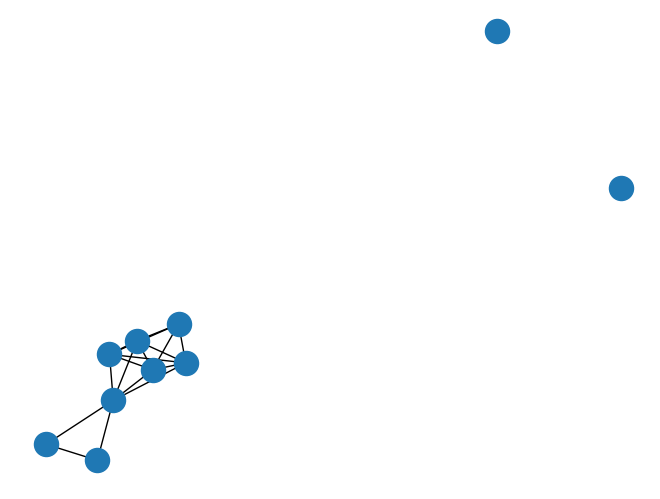

17 20 600


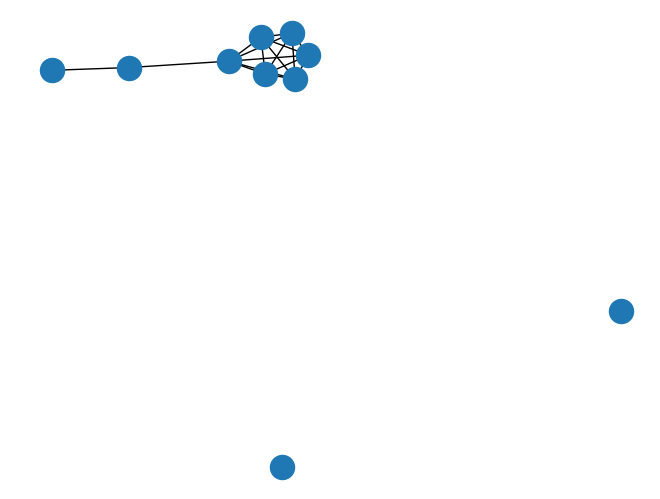

17 20 600


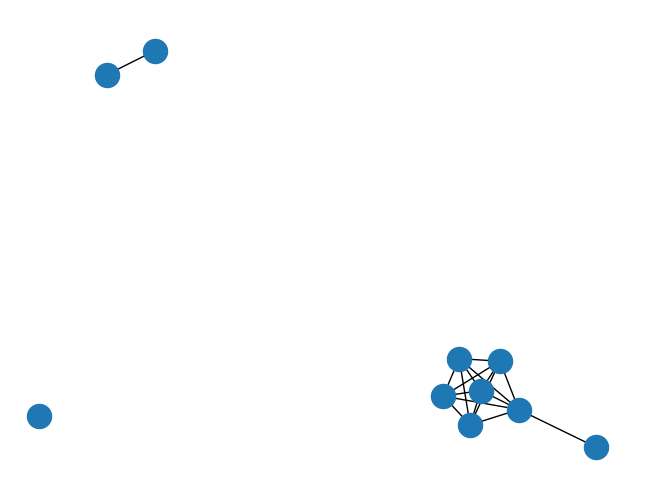

17 16 396


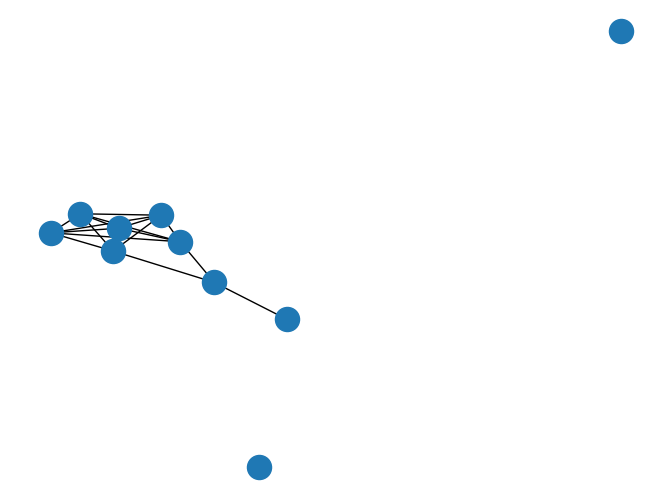

17 16 396


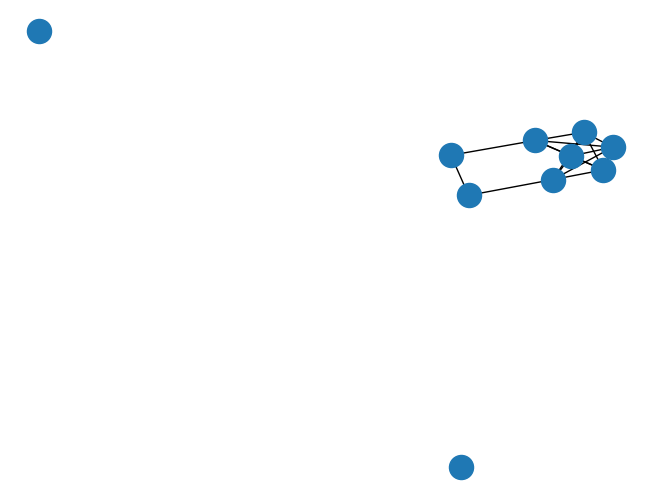

17 16 396


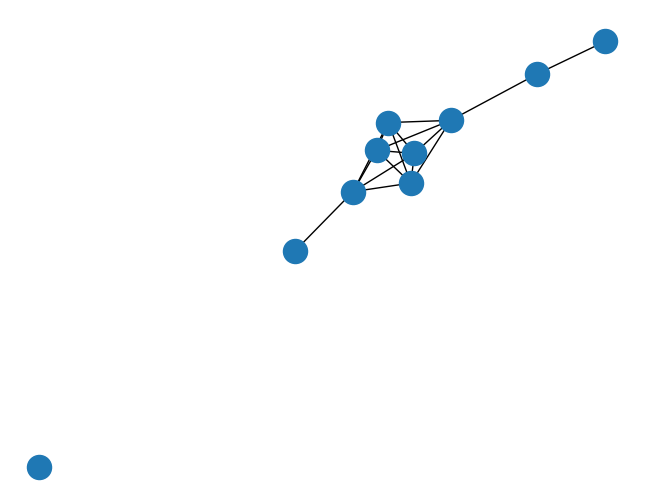

17 16 396


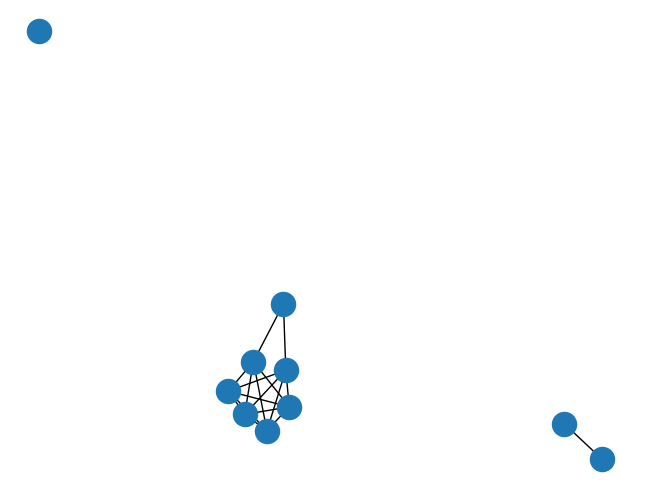

17 16 396


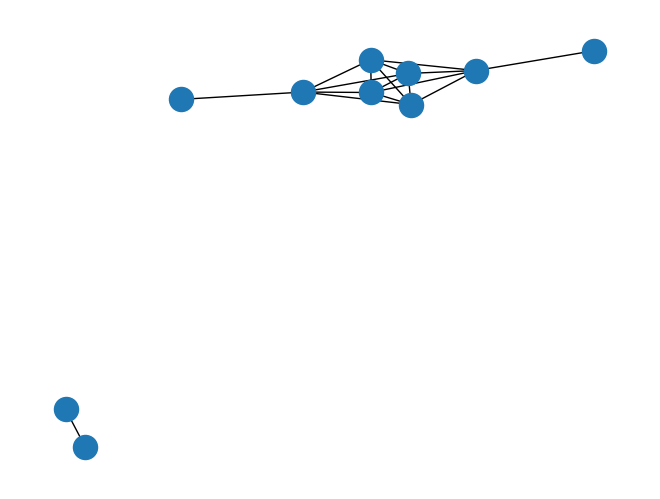

17 16 396


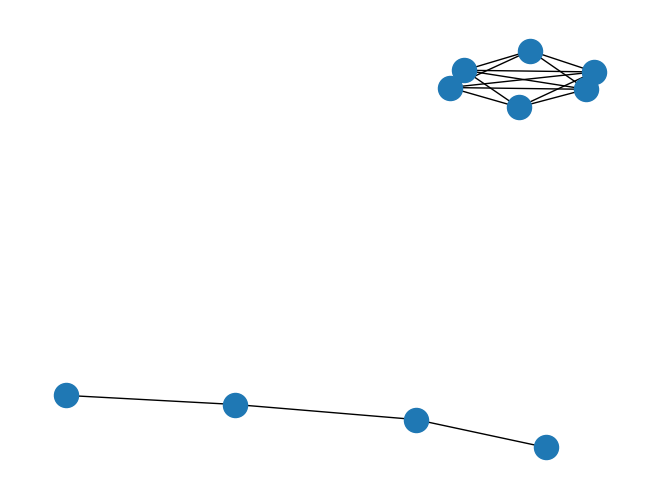

17 16 396


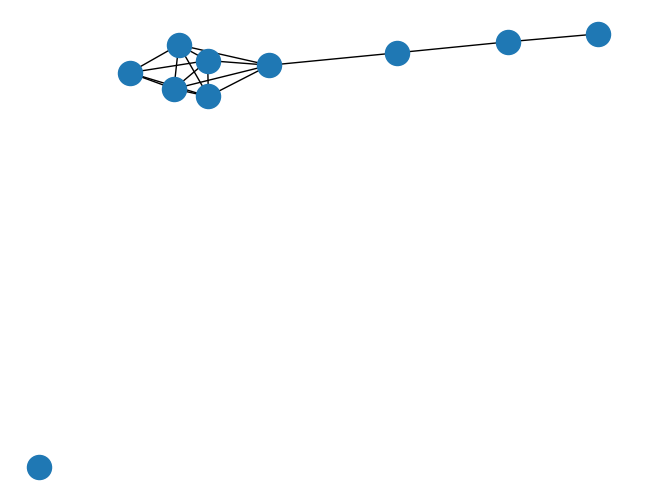

17 16 396


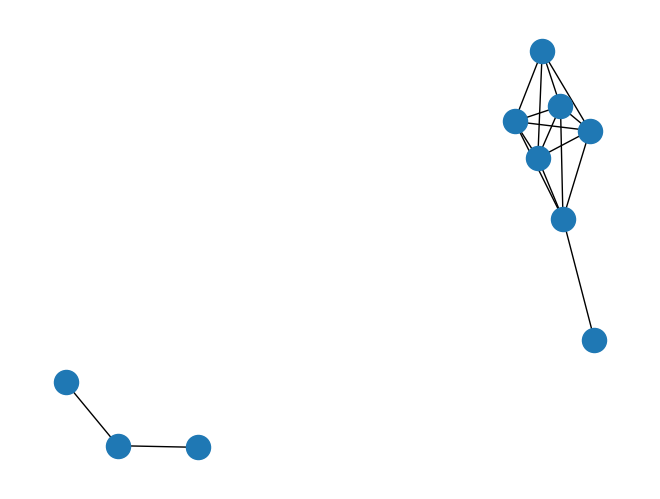

17 20 600


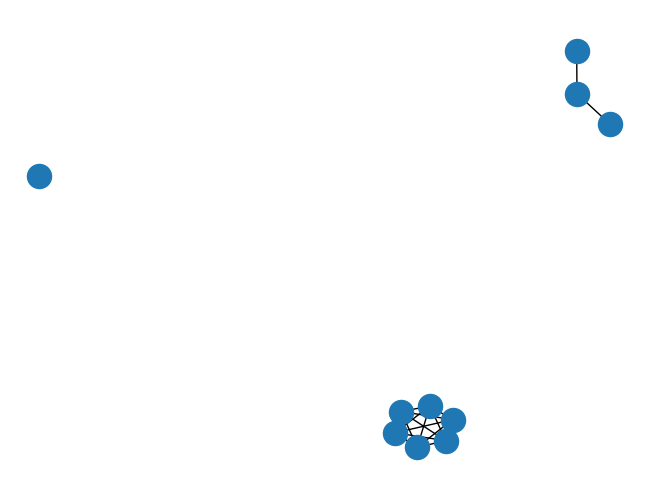

17 17 399


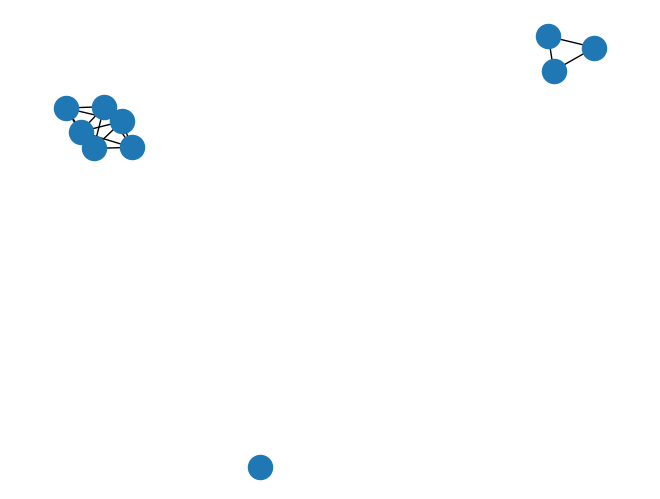

KeyboardInterrupt: 

In [2]:
import subprocess
import networkx as nx
import pynauty as nauty
from collections import Counter
import matplotlib.pyplot as plt
import math
import io

def get_exact_distribution_from_geng(n):
    # geng n -q: generates all non-isomorphic graphs silently
    process = subprocess.Popen(
        ['geng', str(n), '-q'], 
        stdout=subprocess.PIPE, 
        text=True
    )
    
    distribution = Counter()
    n_fact = math.factorial(n)
    
    print(f"Streaming and analyzing graphs for n={n}...")
    
    for line in process.stdout:
        g6_str = line.strip()
        if not g6_str: continue
        
        G = nx.from_graph6_bytes(g6_str.encode())
        m = G.number_of_edges()
        tris = nx.triangles(G)
        t = sum(tris.values()) // 3
        t2 = sum(count**2 for count in tris.values())
        if m == 17 and t>15:
            print(m,t,t2)
            #displaygraph 
            nx.draw(G)
            plt.show()
        
        
       

    process.wait()
    return distribution

n = 10
exact_dist = get_exact_distribution_from_geng(n)
total = 0
print(f"Exact Joint distribution for n={n}:")
for (m, t, t2), count in sorted(exact_dist.items()):
    total += count
    print(f"Edges: {m}, Triangles: {t}, Triangle Squares: {t2} -> Count: {count}")
print(total)
